## Strategy Definition — Chaikin Oscillator (CHO) Long/Short Rules

This strategy uses the Chaikin Oscillator (CHO) to capture shifts in underlying buying and selling pressure *before* they appear in price trends.  
CHO measures the momentum of the Accumulation/Distribution Line (ADL), which incorporates both price location within the daily range and trading volume.

### Intuition
We use a single threshold value:

- When CHO is above the threshold, it indicates stronger buying pressure and bullish momentum.
- When CHO is below the threshold, it indicates weaker or negative buying pressure and potential bearish conditions.

The strategy reacts to whether CHO is above or below this threshold, rather than just zero.

## How CHO Is Constructed

### 1. Money Flow Multiplier (MFM)

$$
\text{MFM}_t =
\frac{(Close_t - Low_t) - (High_t - Close_t)}
     {High_t - Low_t}
$$

Interpretation:
- MFM close to +1 → close near high → buying pressure  
- MFM close to -1 → close near low → selling pressure  
- MFM ≈ 0 → neutral day  

If High_t = Low_t, we set MFM = 0 to avoid division-by-zero.


### 2. Money Flow Volume (MFV)

$$
\text{MFV}_t = \text{MFM}_t \times Volume_t
$$

This weights the MFM by trading volume so high-volume days have a larger impact.


### 3. Accumulation/Distribution Line (ADL)

$$
ADL_t = \sum_{i=1}^{t} MFV_i
$$

- ADL trending upward → accumulation (buying)
- ADL trending downward → distribution (selling)


### 4. Chaikin Oscillator (CHO)

We compute two EMAs of ADL:

- Fast EMA (e.g. 5-period)  
- Slow EMA (e.g. 25-period)

Then:

$$
CHO_t = EMA_{\text{fast}}(ADL_t) - EMA_{\text{slow}}(ADL_t)
$$

- CHO > 0 → fast EMA above slow EMA → upward momentum  
- CHO < 0 → downward momentum  

CHO behaves like a *MACD of the ADL*, combining price location, volume, and momentum.


## Single Threshold Logic

We define a single scalar threshold:

- If CHO_t > threshold → bullish regime  
- If CHO_t < threshold → bearish/weak regime  

## Trading Rules

For each stock and at each time \( t \):

### Long (buy) rules

- Enter long when CHO moves from ≤ threshold to > threshold  
  (i.e. CHO crosses above the threshold).
- Exit long when CHO moves from ≥ threshold to < threshold.

### Short (sell) rules (if allow_short = True)

- Enter short when CHO moves from ≥ threshold to < threshold  
  (i.e. CHO falls below the threshold).
- Exit short when CHO moves from ≤ threshold to > threshold.

In other words:
- Above threshold → prefer long exposure.  
- Below threshold → prefer short exposure (if enabled), or stay flat in a long-only setup.

In [1]:
# Install all important libraries
# !pip install yfinance
# !pip install ta

In [2]:
# import all libraries
import itertools
import math
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

## **Backtesting Infrastructure - `Common_Class`**

In this section, we define a reusable backtesting backbone called `Common_Class`.  
This class handles:

- Downloading and aligning price data across a list of stocks  
- Tracking positions, quantities, and available capital  
- Executing buy/sell orders with transaction costs  
- Recording every trade into a single trade log  
- Computing daily equity, returns, and performance metrics  
- Generating summary performance plots and benchmark (SPY) comparison  

Strategy-specific classes will inherit from this base class and only implement the
entry/exit logic. This keeps the trading engine clean and makes it easier to test
different strategies on the same framework.


In [3]:
class Common_Class():

  def __init__(self, symbol, start, end, interval, capital, transcation_cost, leverage, verbose = True, allow_short=False):
    """
    Parameters:
    - symbol: List of stock tickers to trade.
    - start: Start date for the backtest (e.g. '2010-01-01').
    - end: End date for the backtest (e.g. '2019-12-31').
    - interval: Data frequency (e.g. '1d').
    - capital: Initial capital for the strategy.
    - transcation_cost: Proportional transaction cost (e.g. 0.001 for 0.1% per trade).
    - leverage: Maximum leverage multiplier, for this project we keep it at 0
    - verbose: Boolean, if True, print trade-level logs.
    """
    #new dicts
    self.all_data ={}
    self.position = {} # position also a dict, commonenting out the self.position = 0
    self.quantity = {} # quantity also a dict. initialising with zero quantitties to all the shares
    for stock in symbol:
      self.quantity['{}'.format(stock)] = 0 #can also do at run strategy

    self.symbol = symbol
    self.start = start
    self.end = end
    self.interval = interval
    self.initial_capital = capital # this is the initial capital you want to trade with
    self.capital = capital # this capital will change depending on trades
    self.transaction_cost = transcation_cost # the transaction cost for trading
    self.leverage = leverage
    self.trades = 0 # Number of trades
    self.verbose = verbose # if you want to see detailed output (logs)
    self.allow_short = allow_short
    self.stored_data = pd.DataFrame(columns = ['trade', 'date', 'position', 'price', 'symbol', 'quantity', 'capital']) # to store trade details
    self.prepare_data() # prepares the data

  def prepare_data(self):
    """
    Download OHLCV data for all requested symbols and align them onto a common trading calendar (intersection of dates).
    This ensures all stocks share the same index so that returns and capital series line up properly in time.

    Since we are building a common class for all types of strategy, we will not calculate CHO now.
    We will calculate the returns
    Since most strategies utilise close prices we are only factoring close price. However, you can alter accordingly.
    """
    all_dates = None
    valid_stocks = []

    for i in self.symbol:
        stock_data = yf.Ticker(i)
        hist_stock = stock_data.history(start=self.start, end=self.end, interval=self.interval)
        hist_stock.index = hist_stock.index.tz_localize(None)

        if hist_stock.empty:
            print(f" {i} returned no data in {self.start}–{self.end}, skipping.")
            continue

        bt_data = pd.DataFrame({
            "Close_Price": hist_stock["Close"],
            "High": hist_stock["High"],
            "Low": hist_stock["Low"],
            "Volume": hist_stock["Volume"]
        })

        # Log returns based on close prices
        bt_data["Return"] = np.log(bt_data["Close_Price"] / bt_data["Close_Price"].shift(1))
        bt_data = bt_data.dropna()

        # Build a common date index by intersecting available dates
        if all_dates is None:
            all_dates = bt_data.index
        else:
            all_dates = all_dates.intersection(bt_data.index)

        self.all_data[i] = bt_data
        valid_stocks.append(i)

    # Align all stocks to the same dates
    if all_dates is not None:
        for i in valid_stocks:
            self.all_data[i] = self.all_data[i].reindex(all_dates).ffill().bfill()
    else:
        raise ValueError("No valid data retrieved for any stock!")

    # Update symbol list to valid ones
    self.symbol = valid_stocks
    # print(f"Using aligned data for {len(valid_stocks)} stocks:", valid_stocks)

  def dollars_for_new_entry(self):
    """
    Compute how much capital to allocate to a new position.
    We split remaining capital equally across all tickers that are currently flat (no open position and zero quantity).
    """
    # Count tickers that are FLAT right now
    flats = [s for s in self.symbol if self.position.get(s, 0) == 0 and self.quantity.get(s, 0) == 0]
    n = max(1, len(flats))  # guard
    return self.capital / n

  # Plot the close price series for a given stock.
  def close_graph(self, stock):
    i = str(stock)
    plt.figure(figsize=(15, 5))
    plt.plot(self.all_data[i]["Close_Price"] ,color='black', label='Price', linestyle='dashed')
    plt.xlabel("Days")
    plt.ylabel("Price")
    plt.title("Close Prices of {}".format(i))
    plt.legend()
    plt.grid()
    plt.show()

  def return_date_price(self, bar, stock):
    # A bar is a unit of data at a given time, depends on the interval you choose, it provides you OHLCV and time info
    # Since we have modeled close prices, we will get the price and date
    i = str(stock)
    date = str(self.all_data[i].index[bar])[:10]
    price = self.all_data[i].Close_Price.iloc[bar]
    return date, price

  def realised_balance(self, bar):
    # Returns you the realised capital in your account at a given time period / bar
    date, price = self.return_date_price(bar, self.symbol[0]) # only concerned with date so any stock will do
    print("Date :{} | Realised Balance: {:0.1f}".format(date,self.capital))

  def unrealised_balance(self, bar):
    #Returns you the unrealised capital (trades in progress) in your account at a given time period / bar
    ub = 0
    for stock in self.symbol:
      date, price = self.return_date_price(bar, stock)
      ub =  ub + self.quantity['{}'.format(stock)] *price
    #print("Date :{} | Unrealised Balance: {:0.1f}".format(date,ub))

  def total_balance(self, bar):
    #Unrealised plus realised
    ub = 0
    for stock in self.symbol:
      date, price = self.return_date_price(bar, stock)
      ub =  ub + self.quantity['{}'.format(stock)] *price
    tb = ub + self.capital
    #print("Date :{} | Total Balance: {:0.1f}".format(date,tb))
    return tb

  def store_results(self, trade, date, position, price, symbol, quantity, capital):
    trade_detail = pd.DataFrame({
        "trade": [trade],
        "date": [date],
        "position": [position],
        "price": [price],
        "symbol": [symbol],
        "quantity": [quantity],
        "capital": [capital],
    })
    if self.stored_data.empty:
        self.stored_data = trade_detail
    else:
        self.stored_data = pd.concat([self.stored_data, trade_detail], ignore_index=True)

  def buy_order(self,bar,stock,quantity=None, dollar =None):
    """
    Execute a buy order for a given stock at a given bar.

    You can specify:
    - quantity: number of shares to buy, OR
    - dollar: dollar amount to invest (converted to shares at market price).

    Leverage rule:
    - We do not allow capital to fall below -leverage * initial_capital.
    With leverage = 0, this simply means we cannot let capital go negative (no borrowing of cash for long positions).
    """
    date, price = self.return_date_price(bar,stock)

    # If quantity is not specified, derive it from the dollar amount
    if quantity == None:
      quantity = int(dollar/price)

    # Leverage / capital constraint for longs
    trade_cost = quantity * price * (1 + self.transaction_cost)
    # Minimum allowable cash level given leverage (0 means "no borrowing")
    min_capital = -self.leverage * self.initial_capital
    # If this trade would break the leverage constraint, skip it
    if self.capital - trade_cost < min_capital:
      return

    # Cash decreases by trade value plus transaction costs
    self.capital = self.capital - (trade_cost)

    # Update holdings and position
    self.quantity['{}'.format(stock)] = self.quantity['{}'.format(stock)] + quantity
    self.trades = self.trades + 1
    self.position['{}'.format(stock)] = 1

    # Record equity after the trade
    tb = self.total_balance(bar)
    self.store_results(self.trades, date, self.position['{}'.format(stock)], price, stock, quantity, tb)

    if self.verbose:
      print("Bought {} shares of {} at {:0.1f} per share worth {:0.1f} $".format(quantity,stock, price, quantity * price))
      print('Total quantity for {} is {}'.format(stock,self.quantity['{}'.format(stock)]))
      self.realised_balance(bar)
      #self.unrealised_balance(bar)
      #self.total_balance(bar)


  def sell_order(self,bar,stock, quantity=None, dollar=None):
    """
    Execute a sell order for a given stock at a given bar.

    You can specify:
    - quantity: number of shares to sell, or
    - dollar: dollar amount to liquidate (converted to shares at market price).

    Shorting:
    - This method allows the position quantity to go negative, i.e. to open or increase a short position, even when leverage = 0. Short selling here is
    treated as borrowing shares, not borrowing cash.
    """
    date, price = self.return_date_price(bar, stock)

    # If quantity is not specified, derive it from the dollar amount
    if quantity == None:
      quantity = int(dollar/price)

    if quantity * price > self.capital * (1 + self.leverage):
      return

    # Cash increases by trade value minus transaction costs
    self.capital = self.capital + ((quantity * price)*(1 - self.transaction_cost))

    # Update holdings and position (can go negative → short)
    self.quantity['{}'.format(stock)] = self.quantity['{}'.format(stock)] - quantity
    self.trades = self.trades + 1
    self.position['{}'.format(stock)] = -1

    # Record equity after the trade
    tb = self.total_balance(bar)
    self.store_results(self.trades, date, self.position['{}'.format(stock)], price, stock, quantity, tb)

    if self.verbose:
      print("Sold {} shares of {} at {:0.1f} per share worth {:0.1f} $".format(quantity,stock, price, quantity * price))
      print('Total quantity for {} is {}'.format(stock,self.quantity['{}'.format(stock)]))
      self.realised_balance(bar)
      #self.unrealised_balance(bar)
      #self.total_balance(bar)

  def last_trade(self, bar):
    """
    Close all remaining open positions at the last bar of the backtest.
    Needs to be check for all open positions of all stocks

    For each stock:
    - Convert remaining quantity into cash at the final price.
    - Log the closing trade as either a "buy to cover" (for shorts) or "sell to close" (for longs).
    """
    for stock in self.symbol:
      if self.quantity.get(stock, 0) == 0:
        continue   # already flat, don't create a fake 0-qty trade

      date, price = self.return_date_price(bar, stock)
      last_quantity = self.quantity['{}'.format(stock)]

      self.capital = self.capital + last_quantity * price
      self.quantity['{}'.format(stock)] = 0 # as no more quantity now. all will be settled
      self.trades = self.trades + 1

      if self.position['{}'.format(stock)] == -1: # if closing out a short position
        last_quantity = - last_quantity # to keep a positve nymber in records. Note, self.quantity is always maintianing a +/- sign.
        self.position['{}'.format(stock)] = 1 # to record we are buying to close out
      else:
        last_quantity =  last_quantity # to keep a positve nymber in records
        self.position['{}'.format(stock)] = -1 # to record we are selling to close out

      tb = self.total_balance(bar)
      self.store_results(self.trades, date, self.position['{}'.format(stock)], price, stock, last_quantity, tb)

      if self.verbose:
        print("Closed open trades for {} shares of {} at {:0.1f} per share worth {:0.1f} $".format(last_quantity,stock, price, last_quantity * price))
        #print("--------------Final Balance-----------")
        #self.total_balance(bar)
        #returns = (self.capital - self.initial_capital) /self.initial_capital *100
        #print("------------------------------")
        #print("The total capital at end of strategy: {:0.1f}".format(self.capital))
        #print("The strategy returns on investment are {:0.1f} %".format(returns))
        #print("Total trades by startegy are {:0.1f}".format(self.trades))

    #print("=" *50)
    #print("--------------Final Balance-----------")
    #tb = self.total_balance(bar)
    #print("Total balan from tb is ", tb)
    #print('self.capital is ', self.capital)
    #returns = (self.capital - self.initial_capital) /self.initial_capital *100
    #print("The total capital at end of strategy: {:0.1f}".format(self.capital))
    #print("The strategy returns on investment are {:0.1f} %".format(returns))
    #print("Total trades by startegy are {:0.1f}".format(self.trades))
    #print("=" *50)


## **Chaikin Oscillator Strategy — Class Overview**

This class implements a long/short trading strategy using the Chaikin Oscillator (CHO) with a decision threshold.

### Signal Logic

1. Compute:
   - Money Flow Multiplier (MFM)
   - Money Flow Volume (MFV)
   - Accumulation/Distribution Line (ADL)
   - Chaikin Oscillator (CHO) = EMA_fast(ADL) – EMA_slow(ADL)

2. Use a single scalar threshold to define regimes:
   - Bullish when CHO > threshold
   - Bearish/weak when CHO < threshold

3. Generate trading signals:
   - Long entry: CHO crosses from ≤ threshold to > threshold  
   - Long exit: CHO crosses from ≥ threshold to < threshold  
   - Short entry (if allow_short = True): CHO crosses from ≥ threshold to < threshold  
   - Short exit: CHO crosses from ≤ threshold to > threshold

### Key Features

- Volume-aware momentum indicator via ADL and CHO  
- Single, intuitive threshold parameter controlling regime shifts  
- Supports both long-only and long/short configurations  
- Vectorized calculation of CHO and trading signals for efficient backtesting  

The class outputs a clean signal series (e.g. –1, 0, +1) that can be directly consumed by the backtesting engine.

In [4]:
class CHO_Strategy(Common_Class):
  """
  Chaikin Oscillator (CHO) strategy on top of the Common_Class engine.
  """
  def go_long(self, bar, stock, quantity=None, dollar=None):
    """
    Move into a long position for `stock` at the given bar.

    Steps:
    1. If we are currently short, first buy to cover (go flat).
    2. Then either:
        - buy a specific `quantity` of shares, or
        - invest a `dollar` amount (default: auto allocate via dollars_for_new_entry()).
    """
    # If short, buy to cover first (short -> flat)
    if self.position.get(stock, 0) == -1 and self.quantity.get(stock, 0) < 0:
        self.position[stock] = 0
        self.buy_order(bar, stock, quantity=-self.quantity[stock])
    
    # Block new short entries if capital too low
    if not self.can_open_short(bar, dollar):
      if self.verbose:
          print(f"Skip new short in {stock} at bar {bar}: "
                f"equity < 40% of initial capital.")
      return  # do nothing

    # Then open / add to a long position
    if quantity is not None:
        self.buy_order(bar, stock, quantity=quantity)
    else:
        if dollar == 'all' or dollar is None:
            dollar = self.dollars_for_new_entry()
        self.buy_order(bar, stock, dollar=dollar)
  
  def can_open_short(self, bar, dollar):
    # Risk rule: if total equity below 40% of initial capital, no new shorts
    tb = self.total_balance(bar)
    if tb <= 0.4 * self.initial_capital:
        return False
    return True

  def go_short(self, bar, stock, quantity=None, dollar=None):
    """
    Move into a short position for `stock` at the given bar.

    Steps:
    1. If we are currently long, first sell all shares (go flat).
    2. Then either:
        - sell a specific `quantity` of shares, or
        - sell a `dollar` amount worth of shares.
    """
    # If long, sell to close first (long -> flat)
    if self.position.get(stock, 0) == 1 and self.quantity.get(stock, 0) > 0:
        self.position[stock] = 0
        self.sell_order(bar, stock, quantity=self.quantity[stock])

    # Then open / add to a short position
    if quantity is not None:
        self.sell_order(bar, stock, quantity=quantity)
    else:
        if dollar == 'all' or dollar is None:
            dollar = self.dollars_for_new_entry()
        self.sell_order(bar, stock, dollar=dollar)

  # Close any existing long position in `stock` (go flat)
  def close_long(self, bar, stock):
    if self.position.get(stock, 0) == 1 and self.quantity.get(stock, 0) > 0:
        self.sell_order(bar, stock, quantity=self.quantity[stock])  # go flat

  # Close any existing short position in `stock` (go flat)
  def close_short(self, bar, stock):
    if self.position.get(stock, 0) == -1 and self.quantity.get(stock, 0) < 0:
        self.buy_order(bar, stock, quantity=-self.quantity[stock])  # buy to cover -> flat

  def _compute_cho(self, df, fast=3, slow=10):
    # df: one stock’s DataFrame with High, Low, Close_Price, Volume
    hl_range = (df["High"] - df["Low"]).replace(0, np.nan)  # avoid divide-by-zero
    mfm = (((df["Close_Price"] - df["Low"]) - (df["High"] - df["Close_Price"])) / hl_range).fillna(0.0)
    mfv = mfm * df["Volume"].fillna(0.0)
    adl = mfv.cumsum()
    ema_fast = adl.ewm(span=fast, adjust=False).mean()
    ema_slow = adl.ewm(span=slow, adjust=False).mean()
    cho = ema_fast - ema_slow
    return cho

  def run_strategy(self, fast=3, slow=10, threshold=0.0):
    """
    Single symmetric CHO threshold (>=0) — no EMA filter.
      - Long entry:  CHO crosses UP through +threshold
      - Long exit:   CHO crosses DOWN through -threshold
      - Short entry: CHO crosses DOWN through -threshold (requires allow_short=True)
      - Short exit:  CHO crosses UP through +threshold

    Example:
      threshold=0.1
      -> Go long on CHO crossing above +0.1; exit long on crossing below -0.1.
      -> Go short on CHO crossing below -0.1; exit short on crossing above +0.1.
    """
    if slow <= fast:
      raise ValueError("slow EMA window must be > fast")

    thr = float(threshold)

    self.stop = False
    self.trades = 0
    self.capital = self.initial_capital

    # Initialize positions and compute indicators
    for stock in self.symbol:
      self.quantity[stock] = 0
      self.position[stock] = 0

      df = self.all_data[stock]

      # Compute CHO
      cho = self._compute_cho(df, fast=fast, slow=slow)
      df[f"CHO_{stock}"] = cho

      self.all_data[stock] = df

    # Find first valid index across all indicators
    first_valid_locs = []
    for stock in self.symbol:
      s1 = self.all_data[stock][f"CHO_{stock}"].first_valid_index()
      if s1 is None:
        raise ValueError(f"CHO not computable for {stock} in given window")
      first_valid_locs.append(self.all_data[stock].index.get_loc(s1))

    start_bar = max(first_valid_locs) + 1  # need prev bar for crosses
    n_bars = len(self.all_data[self.symbol[0]])
    last_bar = n_bars - 1  # fallback if loop doesn't run

    # Main backtest loop
    for bar in range(start_bar, n_bars):
      last_bar = bar
      tb = self.total_balance(bar)
      if tb < 0:
        # print("negative capital")
        self.last_trade(bar)
        self.stop = True
        break

      for stock in self.symbol:
        date, price = self.return_date_price(bar, stock)
        df = self.all_data[stock]

        cho_now  = df[f"CHO_{stock}"].iloc[bar]
        cho_prev = df[f"CHO_{stock}"].iloc[bar - 1]

        # Long Entry
        if self.position[stock] in [0, -1]:
          long_cross_up = (cho_prev <= +thr) and (cho_now > +thr)
          if long_cross_up:
            self.go_long(bar, stock)
            continue

        # Short Entry
        if self.position[stock] in [0, 1] and getattr(self, "allow_short", False):
          short_cross_down = (cho_prev >= -thr) and (cho_now < -thr)
          if short_cross_down:
            self.go_short(bar, stock)
            continue

        # Long Exit (go flat)
        if self.position[stock] == 1:
          long_exit = (cho_prev > +thr) and (cho_now <= -thr)
          if long_exit:
            self.close_long(bar, stock)
            continue  # avoid double action same bar

        # Short Exit (go flat)
        if self.position[stock] == -1:
          short_exit = (cho_prev < -thr) and (cho_now >= +thr)
          if short_exit:
            self.close_short(bar, stock)
            continue  # avoid double action same bar

        # store daily snapshot
        store_quantity = abs(self.quantity[stock])
        tb = self.total_balance(bar)
        self.store_results(0, date, self.position[stock], price, stock, store_quantity, tb)

    # At the end, close any remaining positions
    if not self.stop:
      self.last_trade(last_bar)


## **Expanding Window Backtester**

`ExpandingWindowBacktester` runs an **expanding-window, walk-forward backtest** with **grid search hyperparameter tuning** for a given strategy class (e.g. `CHO_Strategy`).

At a high level, it:

1. Splits your full backtest period into **train/test years**.
2. For each test year:
   - **TRAIN** on all data from `start_year` up to `test_year - 1` using grid search over `(fast, slow, threshold)`.
   - Choose the parameter set that maximises a chosen **objective** (`"sharpe"` or `"cagr"`).
   - **TEST** that parameter set on `test_year` only (out-of-sample).
3. Stores:
   - A per-year **summary** of train/test metrics (`self.summary`, a `DataFrame`).
   - Detailed objects per test year (`self.per_year`: capital curves, metrics, best params).
4. Provides:
   - `performance()` → **final Strategy vs Benchmark metrics table**.
   - `performance_plots()` → **plots** of equity curves, drawdown, and buy-and-hold stock returns.

In [5]:
class ExpandingWindowBacktester:
    """
    Runs an expanding-window backtest with grid search over (fast, slow, threshold)

    High-level flow:
      1. For each test year Y (e.g. 2011..2019):
         - Train on [start_year .. Y-1] using grid search over (fast, slow, threshold)
         - Pick the parameter set that maximizes a chosen objective (Sharpe or CAGR)
         - Test that parameter set on year Y (out-of-sample)
      2. For each TRAIN and TEST window, build a capital series and compute metrics
         such as CAGR, volatility, Sharpe, Sortino, max drawdown, alpha, beta, etc
      3. Store a per-year summary in self.summary (DataFrame) and all detailed
         objects (capital curves, metrics, best parameters) in self.per_year
      4. Provide:
           - performance() -> final Strategy vs Benchmark table (average test metrics)
           - performance_plots() -> various plots (strategy vs benchmark equity, drawdown, etc)
    """
    def __init__(self, strategy_cls, stock_list, start_date, end_date,
                initial_capital, transaction_cost, leverage, interval, fast_grid,
                slow_grid, threshold_grid, objective, print_progress):

      self.strategy_cls = strategy_cls
      self.stock_list = stock_list
      self.start_date = str(start_date)
      self.end_date = str(end_date)
      self.initial_capital = initial_capital
      self.transaction_cost = transaction_cost
      self.leverage = leverage
      self.interval = interval
      self.fast_grid = fast_grid
      self.slow_grid = slow_grid
      self.threshold_grid = threshold_grid
      self.objective = objective
      self.print_progress = print_progress

      # Outputs after run_backtest()
      self.summary = None
      self.per_year = {}

    @staticmethod
    def _capital_series_from_stored(stored_df):
      """
      Convert stored trade snapshots into a daily capital time series

      stored_df contains:
        - 'date'   : string / datetime-like
        - 'capital': portfolio capital at the end of that bar
      """
      if stored_df is None or stored_df.empty:
        return pd.Series(dtype=float)
      cap = stored_df.groupby("date")["capital"].mean()
      cap.index = pd.to_datetime(cap.index, errors="coerce")
      cap = cap.dropna().sort_index()
      return cap

    @staticmethod
    def _metrics_from_capital(cap, trades=0, benchmark=None):
      """
      Compute performance metrics from a capital series, optionally vs. a benchmark
      """

      # If there is no usable capital history, return a NaN metric pack.
      if cap is None or len(cap) < 2:
        return {
          "cagr_pct": np.nan, "ann_vol_pct": np.nan, "sharpe": np.nan, "sortino": np.nan,
          "max_dd_pct": np.nan, "alpha": np.nan, "beta": np.nan,
          "n_days": 0, "n_years": 0.0, "trades": trades,
        }

      # Time span
      n_days = (cap.index[-1] - cap.index[0]).days + 1
      n_years = max(n_days / 365.25, 1e-9)

      # Daily returns of strategy
      daily = cap.pct_change().replace([np.inf, -np.inf], np.nan).dropna()

      # Volatility and Sharpe
      if daily.empty or daily.std(ddof=0) == 0:
        ann_vol = np.nan
        sharpe = np.nan
      else:
        ann_vol = daily.std(ddof=0) * math.sqrt(252)
        sharpe = (daily.mean() / daily.std(ddof=0)) * math.sqrt(252)

      # Sortino
      neg = daily[daily < 0]
      sortino = (
        (daily.mean() / neg.std(ddof=0) * math.sqrt(252))
        if len(neg) >= 2 and neg.std(ddof=0) > 0
        else np.nan
      )

      # CAGR
      start_val, end_val = cap.iloc[0], cap.iloc[-1]
      cagr = (end_val / start_val) ** (1 / n_years) - 1

      # Max Drawdown (from equity)
      roll_max = cap.cummax()
      dd = cap / roll_max - 1.0
      max_dd = dd.min()  # negative

      # Alpha and Beta
      alpha_annual = np.nan
      beta = np.nan

      if benchmark is not None and not benchmark.empty:
        bench = benchmark.copy()

        # Make index tz-naive & sorted
        if getattr(bench.index, "tz", None) is not None:
          bench.index = bench.index.tz_localize(None)
        bench = bench.sort_index()

        # Align benchmark prices to cap dates, then compute daily returns
        bench = bench.reindex(cap.index).ffill().bfill()
        bench_daily = bench.pct_change().replace([np.inf, -np.inf], np.nan).dropna()

        # Align on common dates between strategy & benchmark returns
        combined = pd.concat([daily, bench_daily], axis=1, join="inner").dropna()
        combined.columns = ["strategy", "benchmark"]

        if len(combined) >= 2:
          rs = combined["strategy"].values
          rb = combined["benchmark"].values

          # Means
          mean_s = rs.mean()
          mean_b = rb.mean()

          # Covariance and variance
          cov_sb = np.mean((rs - mean_s) * (rb - mean_b))
          var_b = np.mean((rb - mean_b) ** 2)

          if var_b > 0:
            beta = cov_sb / var_b
            alpha_daily = mean_s - beta * mean_b
            alpha_annual = (1.0 + alpha_daily) ** 252 - 1.0

      return {
        "cagr_pct": cagr * 100,
        "ann_vol_pct": ann_vol * 100 if pd.notna(ann_vol) else np.nan,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_dd_pct": max_dd * 100,
        "alpha": alpha_annual,
        "beta": beta,
        "n_days": int(n_days),
        "n_years": float(n_years),
        "trades": trades,
      }

    def _run_once(self, stocks, start, end, fast, slow, threshold, initial_capital=None, tx_cost=None, interval=None, verbose=False):
      """
      Instantiate the strategy, run it on [start, end], and compute metrics
      Used for:
        - TRAIN runs (grid search)
        - TEST runs (using the selected best parameters)
      """
      if initial_capital is None:
          initial_capital = self.initial_capital
      if tx_cost is None:
          tx_cost = self.transaction_cost
      if interval is None:
          interval = self.interval

      try:
        # Instantiate strategy and run actual trading logic
        strat = self.strategy_cls(stocks, start, end, interval, initial_capital, tx_cost, leverage=self.leverage, verbose=verbose, allow_short=True)
        strat.run_strategy(fast=fast, slow=slow, threshold=threshold)

        # Convert trade-level data into daily capital series
        cap = self._capital_series_from_stored(strat.stored_data)
        trades_log = strat.stored_data.copy()

        # If equity ever goes <= 0, mark run as invalid
        if cap is None or len(cap) < 2 or (cap <= 0).any():
          return {
            "capital": cap,
            "metrics": self._metrics_from_capital(pd.Series(dtype=float)),
            "trades_log": pd.DataFrame(),
            "params": {"fast": fast, "slow": slow, "threshold": threshold},
            "ok": False,
          }

        # Fetch benchmark prices and compute metrics for this run
        spy = yf.Ticker("SPY").history(start=start, end=end, interval=interval)
        spy = spy["Close"] if not spy.empty else None
        metrics = self._metrics_from_capital(cap, trades=strat.trades, benchmark=spy)

        return {
          "capital": cap,
          "metrics": metrics,
          "trades_log": trades_log,
          "params": {"fast": fast, "slow": slow, "threshold": threshold},
          "ok": len(cap) >= 2,
        }
      except Exception as e:
        return {
          "capital": pd.Series(dtype=float),
          "metrics": self._metrics_from_capital(pd.Series(dtype=float)),
          "trades_log": pd.DataFrame(),
          "params": {"fast": fast, "slow": slow, "threshold": threshold},
          "ok": False,
          "error": str(e),
        }

    def run_backtest(self, tx_cost=None):
      """
      Perform expanding-window backtest
      Steps:
        - Build a hyperparameter grid over (fast, slow, threshold)
        - Iterate test_year from (start_year + 1) to end_year:
            * For each TRAIN window:
                - Run grid search via _run_once
                - Select best params based on self.objective
            * Run TEST using the best params and record metrics
        - Aggregate per-year rows into self.summary DataFrame
        - Store detailed objects in self.per_year
      """
      # Allow overriding tx_cost per run
      if tx_cost is not None:
        self.transaction_cost = tx_cost

      def _as_iter(x):
        # Ensure that x is an iterable for grid search
        return x if isinstance(x, (list, tuple, range)) else [x]

      # Cartesian product of hyperparameters; filter out slow <= fast for CHO
      grid = list(itertools.product(
        _as_iter(self.fast_grid),
        _as_iter(self.slow_grid),
        _as_iter(self.threshold_grid),
      ))
      grid = [(f, s, t) for (f, s, t) in grid if s > f]

      # Convert global backtest dates to year boundaries
      sd = pd.to_datetime(self.start_date).date()
      ed = pd.to_datetime(self.end_date).date()
      start_year, end_year = sd.year, ed.year

      rows, details = [], {}

      # Format for logging
      def fmt(v, p=3):
        return (
          "nan"
          if (v is None or (isinstance(v, float) and pd.isna(v)))
          else f"{v:.{p}f}"
        )

      # Expanding window loop
      for test_year in range(start_year + 1, end_year + 1):
        # TRAIN range
        train_start = pd.to_datetime(f"{start_year}-01-01").date()
        train_end   = pd.to_datetime(f"{test_year-1}-12-31").date()

        # TEST range
        test_start  = pd.to_datetime(f"{test_year}-01-01").date()
        test_end    = min(pd.to_datetime(f"{test_year}-12-31").date(), ed)
        if test_end < test_start:
            continue

        if self.print_progress:
            print(f"\n=== Train {train_start} → {train_end} | "
                  f"Test {test_start} → {test_end} ===")

        # Grid search over TRAIN data
        best_score = -np.inf
        best = None
        best_train_run = None

        for (f, s, t) in grid:
          r = self._run_once(
            self.stock_list,
            str(train_start),
            str(train_end),
            fast=f,
            slow=s,
            threshold=t,
            initial_capital=self.initial_capital,
            tx_cost=self.transaction_cost,
            interval=self.interval,
            verbose=False,
          )
          if not r["ok"]:
            continue

          m = r["metrics"]

          # Reject param combo with drawdown < -50%
          # if m["max_dd_pct"] < -50:
          #   continue
          
          score = (m["sharpe"] if self.objective == "sharpe" else m["cagr_pct"])
          if pd.isna(score):
            continue
          
          if score > best_score:
            best_score = score
            best = (f, s, t)
            best_train_run = r

        if best is None:
          if self.print_progress:
            print("No valid params on training window; skipping this test year")
          continue

        bf, bs, bt = best
        trm = best_train_run["metrics"]
        best_train_cagr = trm["cagr_pct"]
        best_train_sharpe = trm["sharpe"]

        if self.print_progress:
            print(
                f"  → Best train params: fast={bf}, slow={bs}, thr={bt} | "
                f"train CAGR%={fmt(best_train_cagr, 2)}  "
                f"train Sharpe={fmt(best_train_sharpe, 3)}"
            )

        # Run TEST data with best params
        test_run = self._run_once(
            self.stock_list,
            str(test_start),
            str(test_end),
            fast=bf,
            slow=bs,
            threshold=bt,
            initial_capital=self.initial_capital,
            tx_cost=self.transaction_cost,
            interval=self.interval,
            verbose=False,
        )
        tm = test_run["metrics"]

        # Single summary row for this test_year
        row = {
          "test_year": test_year,
          "train_start": str(train_start), "train_end": str(train_end),
          "test_start": str(test_start),   "test_end":  str(test_end),
          "best_fast": bf, "best_slow": bs, "best_threshold": bt,
          "best_train_CAGR_%": round(best_train_cagr, 2),
          "train_CAGR_%": round(trm["cagr_pct"], 2),
          "train_Vol_%":  round(trm["ann_vol_pct"], 2),
          "train_Sharpe": round(trm["sharpe"], 2) if pd.notna(trm["sharpe"]) else np.nan,
          "train_Sortino":round(trm["sortino"], 2) if pd.notna(trm["sortino"]) else np.nan,
          "train_MaxDD_%":round(trm["max_dd_pct"], 2),
          "train_days":    trm["n_days"],
          "train_trades":  trm["trades"],
          "test_CAGR_%":  round(tm["cagr_pct"], 2),
          "test_Vol_%":   round(tm["ann_vol_pct"], 2),
          "test_Sharpe":  round(tm["sharpe"], 2) if pd.notna(tm["sharpe"]) else np.nan,
          "test_Sortino": round(tm["sortino"], 2) if pd.notna(tm["sortino"]) else np.nan,
          "test_MaxDD_%": round(tm["max_dd_pct"], 2),
          "test_alpha": round(tm["alpha"], 2) if "alpha" in tm else np.nan,
          "test_beta":    round(tm["beta"], 3) if "beta" in tm else np.nan,
          "test_days":    tm["n_days"],
          "test_trades":  tm["trades"],
        }
        rows.append(row)

        # Store detailed metrics and capital
        details[test_year] = {
          "best_params": {"fast": bf, "slow": bs, "threshold": bt},
          "train_capital": best_train_run["capital"],
          "test_capital":  test_run["capital"],
          "train_metrics": trm,
          "test_metrics":  tm,
          "test_trades":   test_run["trades_log"],
        }

        if self.print_progress:
          print(
            f"  → Test {test_year}: Sharpe={fmt(row['test_Sharpe'], 3)}, "
            f"CAGR%={fmt(row['test_CAGR_%'], 2)}, "
            f"MaxDD%={fmt(row['test_MaxDD_%'], 2)}"
          )

      # Build final summary dataframe
      summary = pd.DataFrame(rows).sort_values("test_year").reset_index(drop=True)
      self.summary = summary
      self.per_year = details

      if self.print_progress and not summary.empty:
        try:
          display(summary)
        except NameError:
          print(summary.to_string(index=False))

      return {"summary": summary, "per_year": details}

    def _average_strategy_test_metrics(self):
      """
        Take the mean of all TEST metrics across all test cycles
      """
      if self.summary is None or self.summary.empty:
        raise ValueError("run_backtest() must be called before averaging test metrics")

      df = self.summary.copy()

      metric_map = {
        "CAGR_%":  "test_CAGR_%",
        "Vol_%":   "test_Vol_%",
        "Sharpe":  "test_Sharpe",
        "Sortino": "test_Sortino",
        "MaxDD_%": "test_MaxDD_%",
        "Alpha":   "test_alpha",
        "Beta":    "test_beta",
      }

      out = {}
      for row_name, col_name in metric_map.items():
        out[row_name] = df[col_name].mean() if col_name in df.columns else np.nan

      return pd.Series(out)

    def _compute_benchmark_metrics(self, benchmark_symbol="SPY"):
      """ Compute benchmark metrics over the testing periods """
      if self.summary is None or self.summary.empty:
        raise ValueError("run_backtest() must be called before computing benchmark metrics")

      df = self.summary.copy()

      if df.empty:
        raise ValueError("No test rows in the specified year range")

      # Overall benchmark window: min(test_start) -> max(test_end)
      start_dates = pd.to_datetime(df["test_start"])
      end_dates   = pd.to_datetime(df["test_end"])
      overall_start = start_dates.min()
      overall_end   = end_dates.max()

      # Pull benchmark prices
      bench = yf.Ticker(benchmark_symbol).history(start=overall_start, end=overall_end, interval=self.interval)

      if getattr(bench.index, "tz", None) is not None:
        bench.index = bench.index.tz_localize(None)
      bench = bench.sort_index()

      # Build equity from simple returns (start at 1.0)
      daily_ret = bench["Close"].pct_change().replace([np.inf, -np.inf], np.nan).dropna()
      if daily_ret.empty:
        raise ValueError("Benchmark daily returns are empty after cleaning")

      equity = (1.0 + daily_ret).cumprod()
      equity.name = f"{benchmark_symbol}_equity"

      # Reuse the same metrics logic as strategy
      metrics = self._metrics_from_capital(equity, trades=0)

      # Map to same naming convention
      out = {
        "CAGR_%":  metrics["cagr_pct"],
        "Vol_%":   metrics["ann_vol_pct"],
        "Sharpe":  metrics["sharpe"],
        "Sortino": metrics["sortino"],
        "MaxDD_%": metrics["max_dd_pct"],
      }
      return pd.Series(out)

    def performance(self, benchmark_symbol="SPY"):
      """
      Build and print final Strategy vs Benchmark comparison table

      Strategy:
        - Uses the average TEST metrics across all cycles (out-of-sample)
      Benchmark:
        - Uses buy-and-hold metrics over the union of all test periods
      """
      strat_avg = self._average_strategy_test_metrics()
      bench_avg = self._compute_benchmark_metrics(benchmark_symbol=benchmark_symbol)

      metrics_index = ["CAGR_%", "Vol_%", "Sharpe", "Sortino", "MaxDD_%", "Alpha", "Beta"]

      strategy_vals = {
        "CAGR_%":  strat_avg.get("CAGR_%",  np.nan),
        "Vol_%":   strat_avg.get("Vol_%",   np.nan),
        "Sharpe":  strat_avg.get("Sharpe",  np.nan),
        "Sortino": strat_avg.get("Sortino", np.nan),
        "MaxDD_%": strat_avg.get("MaxDD_%", np.nan),
        "Alpha":   strat_avg.get("Alpha",   np.nan),
        "Beta":    strat_avg.get("Beta",    np.nan),
      }

      benchmark_vals = {
        "CAGR_%":  bench_avg.get("CAGR_%",  np.nan),
        "Vol_%":   bench_avg.get("Vol_%",   np.nan),
        "Sharpe":  bench_avg.get("Sharpe",  np.nan),
        "Sortino": bench_avg.get("Sortino", np.nan),
        "MaxDD_%": bench_avg.get("MaxDD_%", np.nan),
        "Alpha":   0.00,
        "Beta":    1.00,
      }

      table = pd.DataFrame(
        {
          "Strategy":  [strategy_vals.get(m, np.nan) for m in metrics_index],
          "Benchmark": [benchmark_vals.get(m, np.nan) for m in metrics_index],
        },
        index=metrics_index,
      )

      print(f"Final Strategy vs Benchmark Comparison")
      print(table.to_string(float_format=lambda x: f"{x:0.2f}" if pd.notna(x) else "nan"))

      return table

    def _collect_all_test_trades(self):
      """
      Concatenate all test-window trade logs from self.per_year into a single Dataframe
      """
      frames = []
      for year, ydata in self.per_year.items():
        tdf = ydata.get("test_trades")
        if tdf is not None and not tdf.empty:
          frames.append(tdf.copy())

      if not frames:
        return pd.DataFrame()

      trades = pd.concat(frames, ignore_index=True)
      trades["date"] = pd.to_datetime(trades["date"])
      return trades
    
    def _position_series_for_stock(self, symbol, price_index, trades_all):
      """
      Build a daily position series for one stock over the given price_index
      """
      # Filter trades for this symbol
      sym_trades = trades_all[trades_all["symbol"] == symbol].copy()
      if sym_trades.empty:
        # All flat
        return pd.Series(0, index=price_index, dtype=float)

      sym_trades = sym_trades.sort_values("date")
      sym_trades["date"] = pd.to_datetime(sym_trades["date"])

      # Start flat
      pos = pd.Series(0.0, index=price_index)
      current_pos = 0.0

      for _, row in sym_trades.iterrows():
        d = row["date"]
        # Skip trades that fall outside our price index range
        if d > pos.index[-1]:
          continue

        # Find first trading day >= d
        loc = pos.index.searchsorted(d)   # integer position
        if loc >= len(pos.index):
            # no index element >= d
            continue
        d_idx = pos.index[loc]

        # If quantity is 0, treat as flat, else use sign in 'position'
        if "quantity" in row and row["quantity"] == 0:
            current_pos = 0.0
        else:
            current_pos = float(row["position"])

        # From this date onwards, hold that position
        pos.loc[d_idx:] = current_pos
        
      return pos

    def performance_plots(self, benchmark_symbol="SPY", initial_equity=1.0):
      """
      Plot:
        1. Cumulative returns of every stock (buy & hold, equal start)
        2. Strategy vs Benchmark (cumulative equity)
        3. Strategy max drawdown
        4. Strategy equity curve
        5. Trade signals (buy/long vs sell/short) for stocks
      """
      if self.summary is None or self.summary.empty or not self.per_year:
            raise ValueError("run_backtest() must be called before performance_plots().")

      df_summary = self.summary

      start_dates = pd.to_datetime(df_summary["test_start"])
      end_dates   = pd.to_datetime(df_summary["test_end"])
      overall_start = start_dates.min().date()
      overall_end   = end_dates.max().date()

      # Build chained strategy equity curve from all test cycles
      eq_list = []
      current_eq = float(initial_equity)

      # Iterate in chronological order of test_year
      for year in sorted(self.per_year.keys()):
        year_data = self.per_year[year]
        cap = year_data["test_capital"]

        if cap is None or len(cap) < 2:
            continue

        cap = cap.sort_index()
        # normalize this year's capital to 1.0 at start
        rel = cap / cap.iloc[0]
        # scale by current_eq so equity continues from previous year
        year_eq = current_eq * rel

        # append, and update current_eq for the next cycle
        eq_list.append(year_eq)
        current_eq = year_eq.iloc[-1]

      if not eq_list:
        raise ValueError("No valid test_capital series found in per_year.")

      # concat and, in case of overlapping dates, keep the last value
      strat_eq = pd.concat(eq_list)
      strat_eq = strat_eq[~strat_eq.index.duplicated(keep="last")]
      strat_eq = strat_eq.sort_index()
      strat_eq.name = "Strategy_Equity"

      # Strategy daily returns
      strat_ret = strat_eq.pct_change().replace([np.inf, -np.inf], np.nan).dropna()

      # Benchmark buy & hold over window
      bench_hist = yf.Ticker(benchmark_symbol).history(
          start=overall_start,
          end=overall_end,
          interval=self.interval,
      )

      if bench_hist.empty:
          raise ValueError(f"No benchmark data found for {benchmark_symbol}")

      if getattr(bench_hist.index, "tz", None) is not None:
          bench_hist.index = bench_hist.index.tz_localize(None)
      bench_hist = bench_hist.sort_index()

      bench_close = bench_hist["Close"]
      bench_close = bench_close.reindex(strat_eq.index).ffill().bfill()
      bench_ret = bench_close.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
      bench_eq = (1.0 + bench_ret).cumprod()
      bench_eq.name = f"{benchmark_symbol}_Equity"

      # Build cumulative returns per stock
      stock_equities = {}
      stock_prices   = {}

      for sym in self.stock_list:
        try:
          h = yf.Ticker(sym).history(start=overall_start, end=overall_end, interval=self.interval)
          if h.empty:
            continue
          if getattr(h.index, "tz", None) is not None:
            h.index = h.index.tz_localize(None)
          h = h.sort_index()
          close = h["Close"].reindex(strat_eq.index).ffill().bfill()
          r = close.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
          eq = (1.0 + r).cumprod()
          eq.name = sym
          stock_equities[sym] = eq
          stock_prices[sym] = close # Store price series for trade signal and position view plotting
        except Exception as e:
          print(f"Skipping {sym} in stock plot due to error: {e}")

      # Max drawdown (MDD)
      peak = strat_eq.cummax()
      dd = strat_eq / peak - 1.0  # in [-1, 0]
      dd.name = "Drawdown"


      # Plot all the graphs together
      fig, axes = plt.subplots(2, 2, figsize=(18, 10))
      fig.suptitle("Performance Plots", fontsize=14)

      # 1. Cumulative returns of every stock
      ax1 = axes[0, 0]
      if stock_equities:
          for sym, eq in stock_equities.items():
              ax1.plot(eq.index, eq.values, label=sym)
      ax1.set_title("Cumulative Returns of Each Stock (Buy & Hold, normalized)")
      ax1.set_xlabel("Date")
      ax1.set_ylabel("Equity (start=1.0)")
      ax1.grid(True)
      if stock_equities:
          ax1.legend()

      # 2. Strategy vs Benchmark (cumulative equity)
      ax2 = axes[0, 1]
      ax2.plot(strat_eq.index, strat_eq.values, label="Strategy")
      ax2.plot(bench_eq.index, bench_eq.values, label=benchmark_symbol, linestyle="--")
      ax2.set_title("Strategy vs Benchmark (Cumulative Equity)")
      ax2.set_xlabel("Date")
      ax2.set_ylabel("Equity (start=1.0)")
      ax2.grid(True)
      ax2.legend()

      # 3. Maximum drawdown (strategy)
      ax3 = axes[1, 0]
      ax3.plot(dd.index, dd.values * 100.0)
      ax3.set_title("Strategy Maximum Drawdown")
      ax3.set_xlabel("Date")
      ax3.set_ylabel("Drawdown (%)")
      ax3.grid(True)

      # 4. Strategy equity curve
      ax4 = axes[1, 1]
      ax4.plot(strat_eq.index, strat_eq.values)
      ax4.set_title("Strategy Equity Curve (Chained Test Cycles)")
      ax4.set_xlabel("Date")
      ax4.set_ylabel("Equity (start=1.0)")
      ax4.grid(True)

      plt.tight_layout(rect=[0, 0.03, 1, 0.96])
      plt.show()

      trades_all = self._collect_all_test_trades()
      if trades_all.empty:
          print("No test trades available for price/signal plots.")
          return

      for sym in self.stock_list:
        # Price data for current symbol
        hist = yf.Ticker(sym).history(
            start=overall_start,
            end=overall_end,
            interval=self.interval,
        )
        if hist.empty:
            continue
        if getattr(hist.index, "tz", None) is not None:
            hist.index = hist.index.tz_localize(None)
        hist = hist.sort_index()
        price = hist["Close"]
        price.name = f"{sym} Close"

        # Filter trades for this symbol
        sym_trades = trades_all[trades_all["symbol"] == sym].copy()
        if sym_trades.empty:
            continue

        sym_trades = sym_trades.sort_values("date")
        sym_trades["date"] = pd.to_datetime(sym_trades["date"])

        # Detect real entry signals (position change events)
        sym_trades["pos_change"] = sym_trades["position"].diff().fillna(sym_trades["position"])
        entries = sym_trades[sym_trades["pos_change"] != 0]

        # Classify entries: new position 1 = long entry, -1 = short entry
        long_entries  = entries[entries["position"] == 1]
        short_entries = entries[entries["position"] == -1]

        # 5. Price + trade signals 
        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(price.index, price.values, label=f"{sym} Close")

        if not long_entries.empty:
            ax.scatter(long_entries["date"], long_entries["price"],
                      marker="^", color="green", label="Buy / Long Entry", zorder=5)
        if not short_entries.empty:
            ax.scatter(short_entries["date"], short_entries["price"],
                      marker="v", color="red", label="Sell / Short Entry", zorder=5)

        ax.set_title(f"{sym} — Price with Strategy Trade Signals (Test Periods)")
        ax.set_xlabel("Date")
        ax.set_ylabel("Price")
        ax.grid(True)
        ax.legend()
        plt.tight_layout()
        plt.show()

        # 6. Long/Short position view
        pos_series = self._position_series_for_stock(sym, price.index, trades_all)

        fig, ax = plt.subplots(figsize=(14, 3))
        ax.step(pos_series.index, pos_series.values, where="post", label=f"{sym} Position")

        ax.set_yticks([-1, 0, 1])
        ax.set_yticklabels(["Short (-1)", "Flat (0)", "Long (+1)"])
        ax.set_title(f"{sym} — Long/Short Position View")
        ax.set_xlabel("Date")
        ax.set_ylabel("Position")
        ax.grid(True)
        ax.legend()
        plt.tight_layout()
        plt.show()
        


=== Train 2010-01-01 → 2010-12-31 | Test 2011-01-01 → 2011-12-31 ===
  → Best train params: fast=10, slow=25, thr=-0.1 | train CAGR%=72.79  train Sharpe=2.314
  → Test 2011: Sharpe=-0.520, CAGR%=-22.00, MaxDD%=-32.16

=== Train 2010-01-01 → 2011-12-31 | Test 2012-01-01 → 2012-12-31 ===
  → Best train params: fast=10, slow=25, thr=-0.1 | train CAGR%=35.67  train Sharpe=1.229
  → Test 2012: Sharpe=1.290, CAGR%=54.65, MaxDD%=-18.86

=== Train 2010-01-01 → 2012-12-31 | Test 2013-01-01 → 2013-12-31 ===
  → Best train params: fast=10, slow=25, thr=-0.1 | train CAGR%=34.00  train Sharpe=1.227
  → Test 2013: Sharpe=2.130, CAGR%=37.28, MaxDD%=-8.10

=== Train 2010-01-01 → 2013-12-31 | Test 2014-01-01 → 2014-12-31 ===
  → Best train params: fast=10, slow=25, thr=-0.1 | train CAGR%=35.25  train Sharpe=1.314
  → Test 2014: Sharpe=2.960, CAGR%=87.43, MaxDD%=-9.67

=== Train 2010-01-01 → 2014-12-31 | Test 2015-01-01 → 2015-12-31 ===
  → Best train params: fast=10, slow=25, thr=-0.1 | train CAGR%=36

,test_year,train_start,train_end,test_start,test_end,best_fast,best_slow,best_threshold,best_train_CAGR_%,train_CAGR_%,...,train_trades,test_CAGR_%,test_Vol_%,test_Sharpe,test_Sortino,test_MaxDD_%,test_alpha,test_beta,test_days,test_trades
0,2011,2010-01-01,2010-12-31,2011-01-01,2011-12-31,10,25,-0.1,72.79,72.79,...,64,-22.00,35.31,-0.52,-0.69,-32.16,-0.19,0.772,360,82
1,2012,2010-01-01,2011-12-31,2012-01-01,2012-12-31,10,25,-0.1,35.67,35.67,...,137,54.65,39.69,1.29,2.81,-18.86,0.49,0.930,359,52
2,2013,2010-01-01,2012-12-31,2013-01-01,2013-12-31,10,25,-0.1,34.00,34.00,...,183,37.28,15.50,2.13,3.26,-8.10,0.11,0.860,361,80
3,2014,2010-01-01,2013-12-31,2014-01-01,2014-12-31,10,25,-0.1,35.25,35.25,...,250,87.43,22.01,2.96,5.88,-9.67,0.72,0.698,359,75
4,2015,2010-01-01,2014-12-31,2015-01-01,2015-12-31,10,25,-0.1,36.43,36.43,...,304,38.22,22.97,1.52,2.39,-15.46,0.32,1.140,359,80
5,2016,2010-01-01,2015-12-31,2016-01-01,2016-12-31,10,25,-0.1,37.29,37.29,...,369,14.60,25.01,0.67,0.86,-18.11,0.07,0.647,360,74
6,2017,2010-01-01,2016-12-31,2017-01-01,2017-12-31,10,25,-0.1,34.21,34.21,...,426,28.67,19.42,1.39,1.81,-10.91,-0.01,1.460,359,56
7,2018,2010-01-01,2017-12-31,2018-01-01,2018-12-31,10,25,-0.1,36.25,36.25,...,472,3.35,25.10,0.26,0.33,-19.50,0.16,1.351,359,76
8,2019,2010-01-01,2018-12-31,2019-01-01,2019-12-31,10,25,-0.1,32.88,32.88,...,536,26.58,13.85,1.78,2.32,-10.75,0.05,0.747,361,57


Final Strategy vs Benchmark Comparison
         Strategy  Benchmark
CAGR_%      29.86      13.12
Vol_%       24.32      14.30
Sharpe       1.28       0.94
Sortino      2.11       1.17
MaxDD_%    -15.95     -19.35
Alpha        0.19       0.00
Beta         0.96       1.00


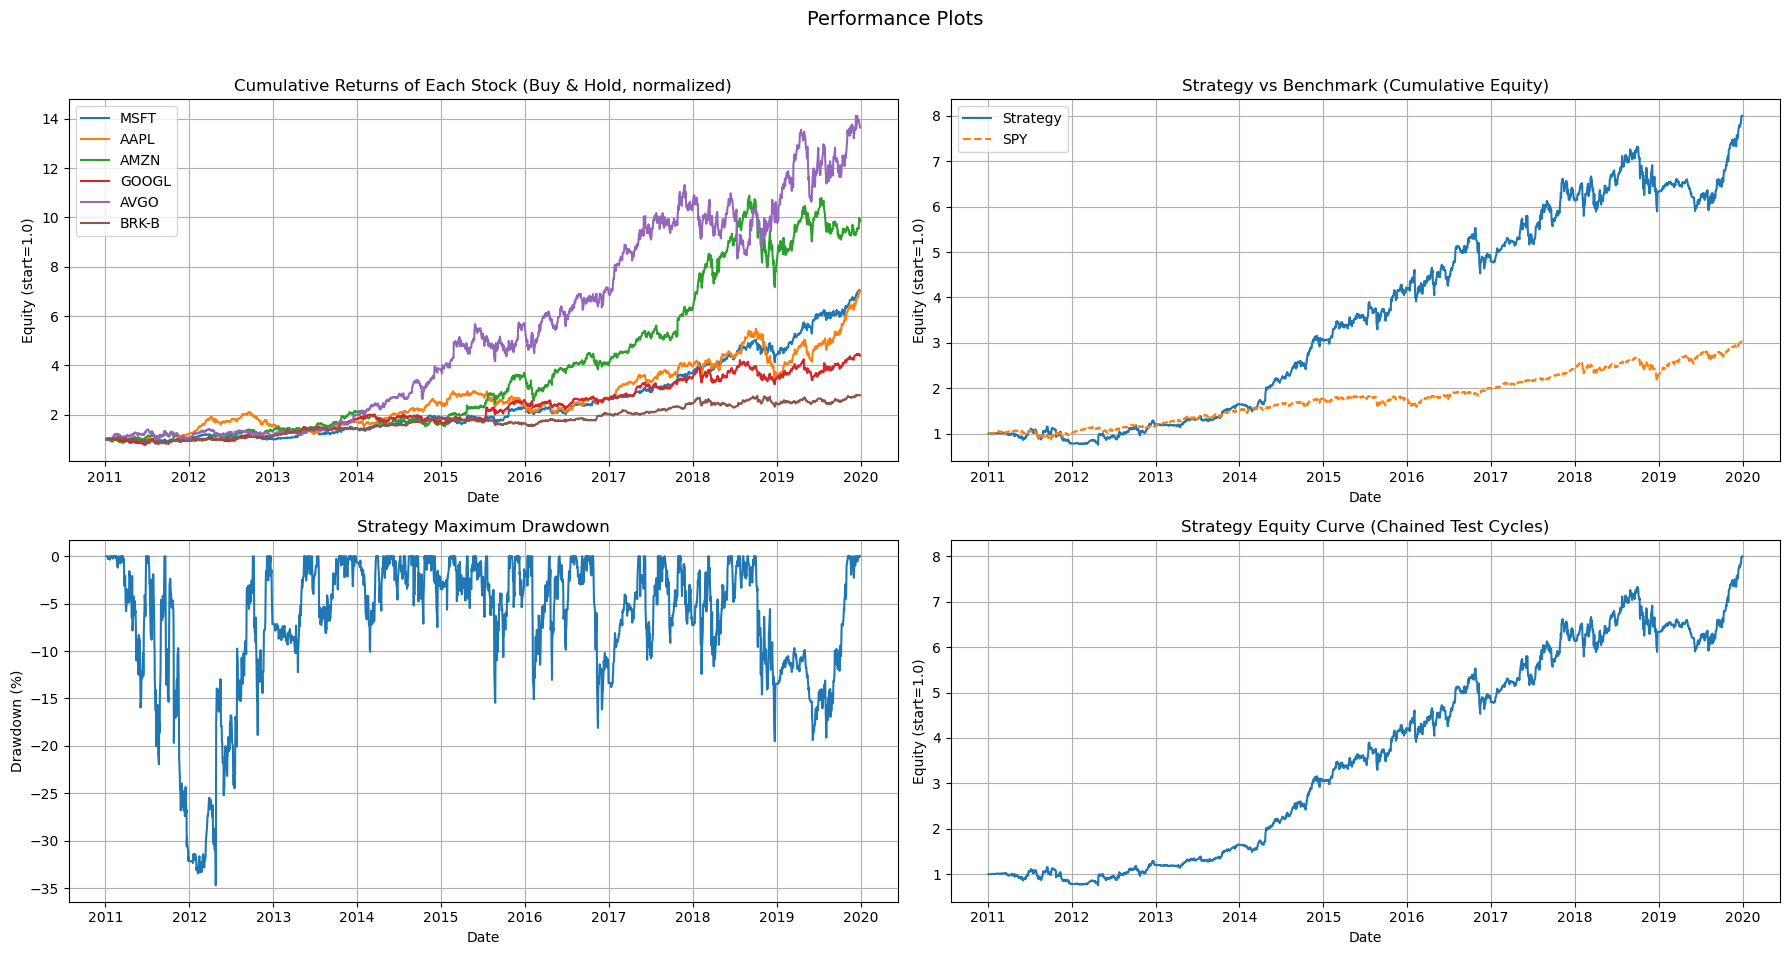

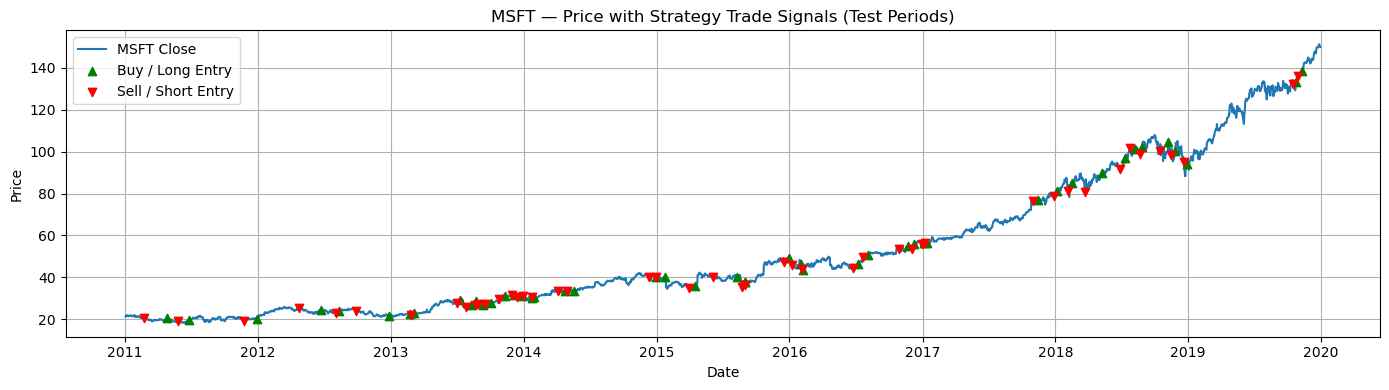

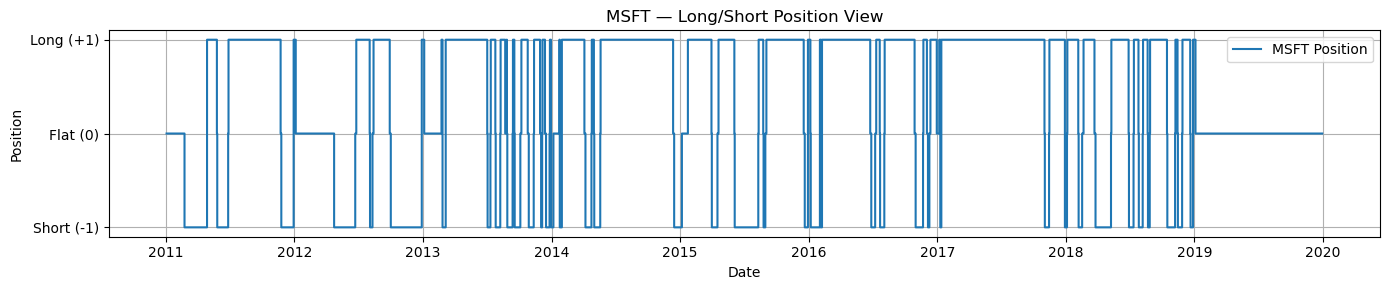

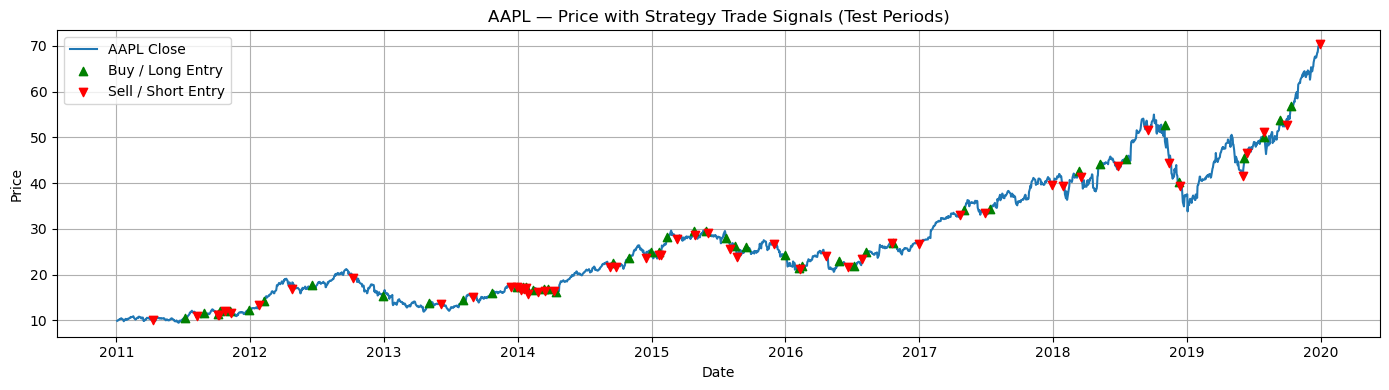

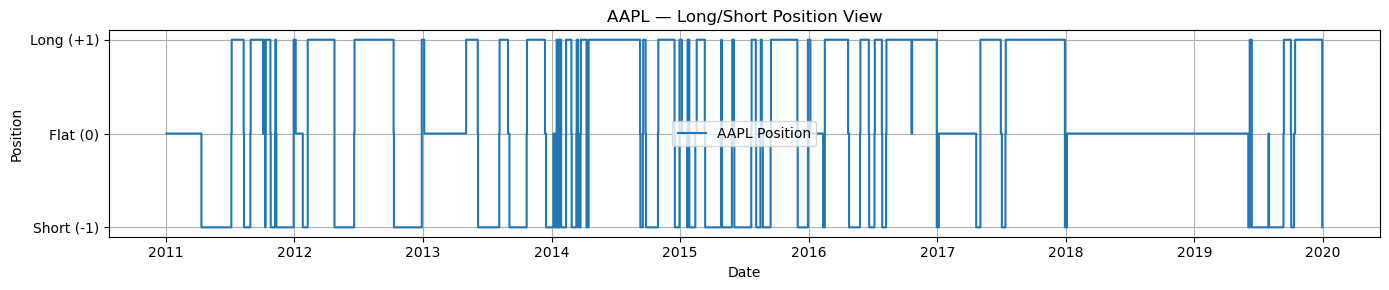

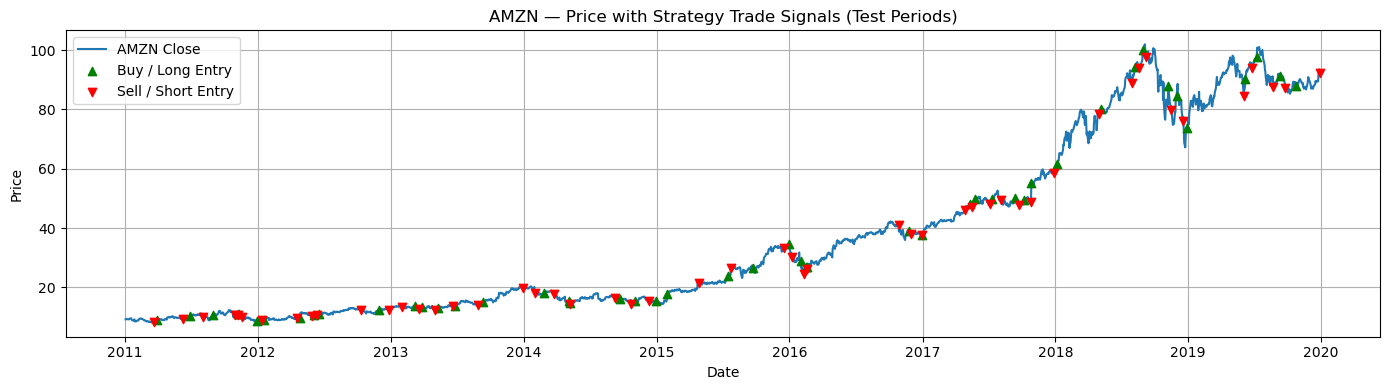

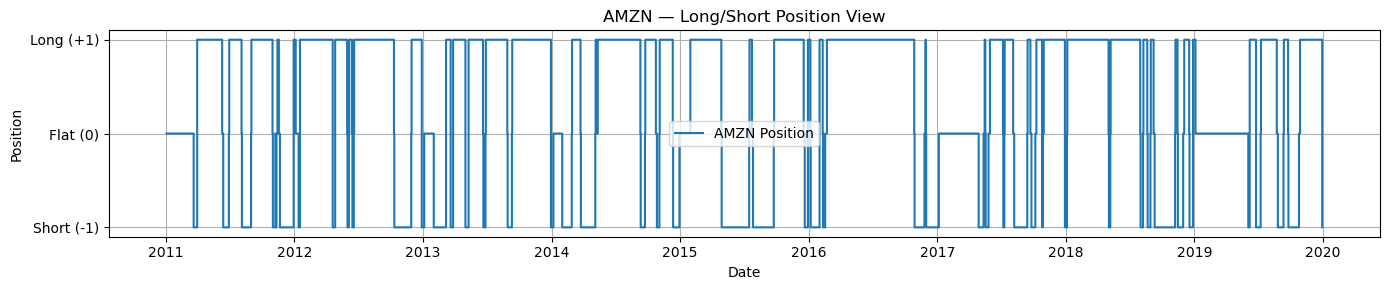

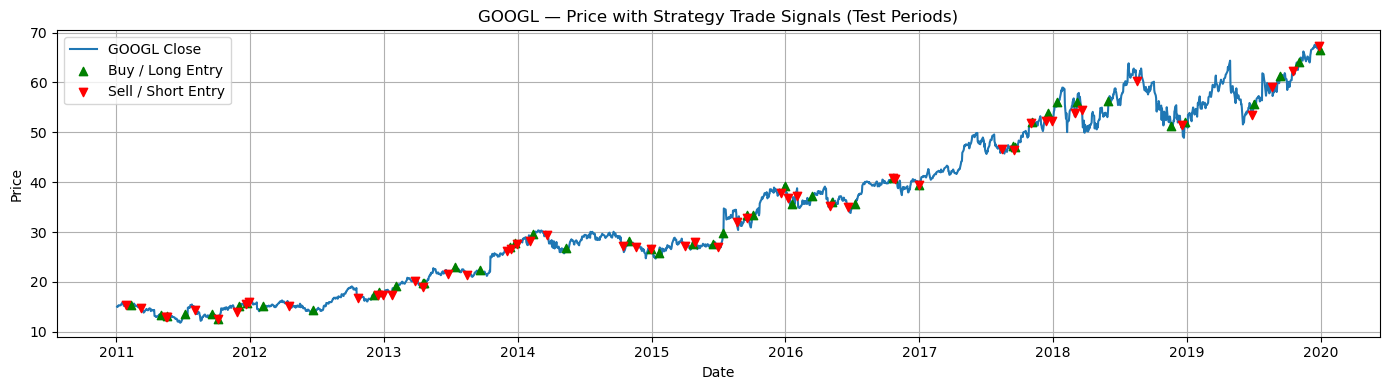

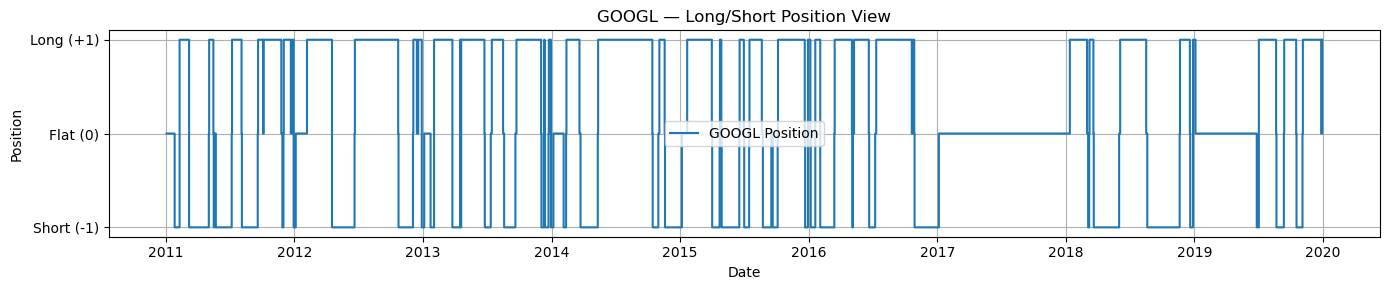

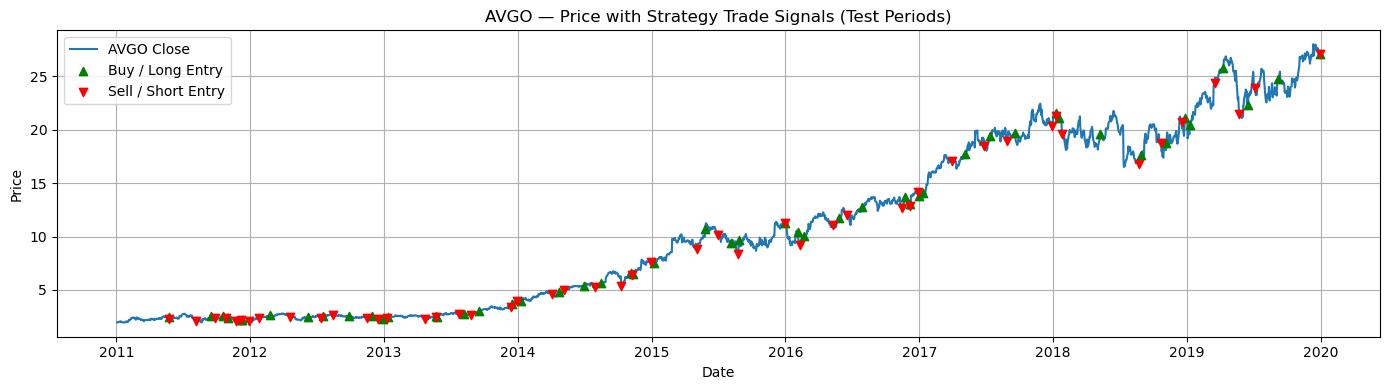

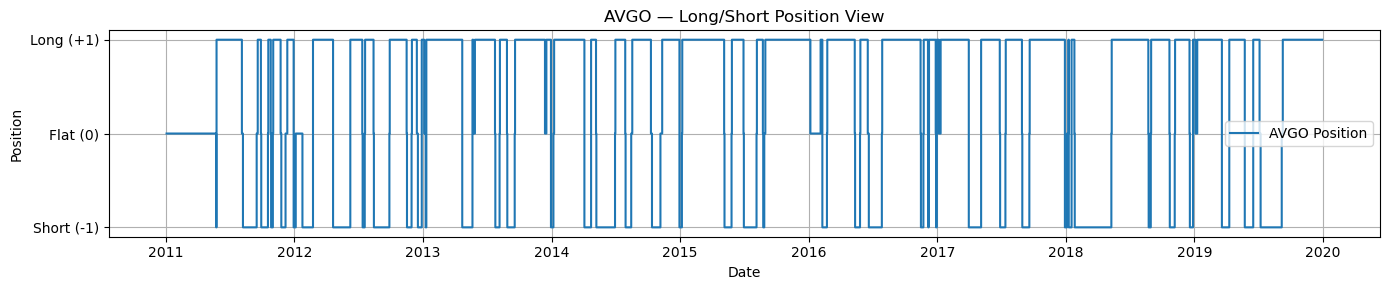

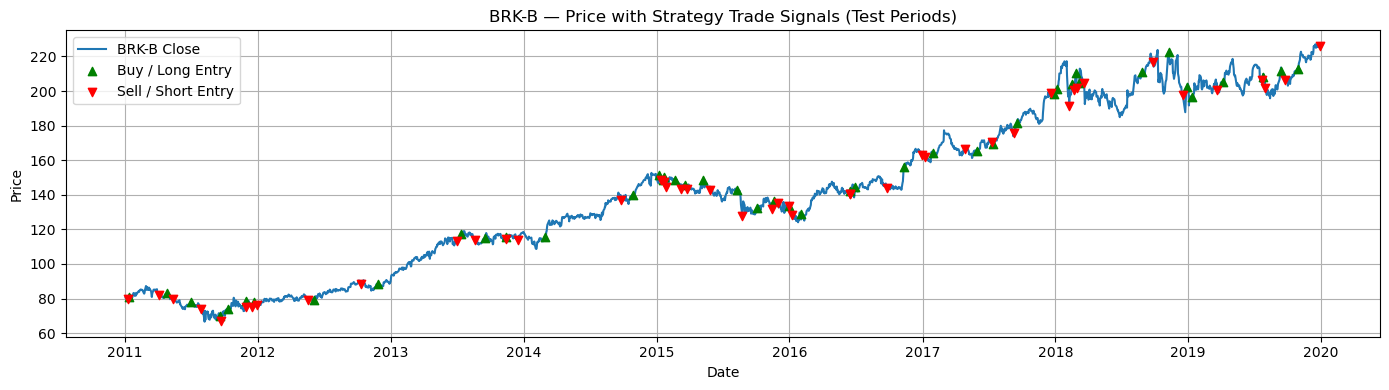

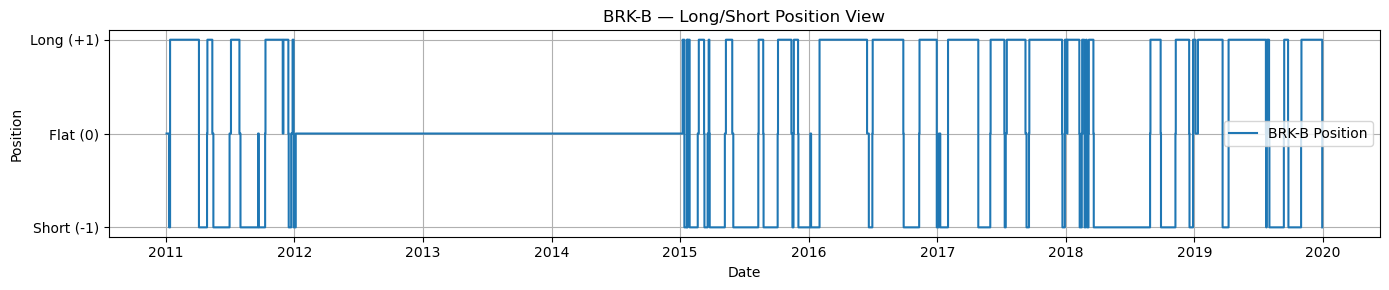

In [6]:
# -----------------------------
# FINAL NOTEBOOK CELL
# -----------------------------

# Initialise backtester instance, define parameters
bt = ExpandingWindowBacktester(
  strategy_cls=CHO_Strategy,
  stock_list=['MSFT', 'AAPL', 'AMZN', "GOOGL", "AVGO", 'BRK-B'],
  start_date="2010-01-01",
  end_date="2019-12-31",
  initial_capital=500_000,
  transaction_cost=0.0,
  leverage=0.0,
  interval="1d",
  fast_grid=(5, 7, 10),
  slow_grid=(20, 25, 28),
  threshold_grid=(-0.1, 0.0),
  objective="sharpe",              # Either 'sharpe' or 'cagr'
  print_progress=True,
)

# Run backtest, performance metrics and performance plots
bt.run_backtest()
bt.performance()
bt.performance_plots()